In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

path_listings = "../data/listings.csv"
listings = pd.read_csv(path_listings)
print(f"listings: {listings.shape[0]:,} elan, {listings.shape[1]} sütun")

listings['price'] = listings['price'].str.replace('[$,]', '', regex=True).astype(float)

print(f"\nPrice sütunu təmizləndikdən sonra: {listings['price'].dtype}")
listings[['id', 'price', 'neighbourhood_cleansed', 'room_type', 'minimum_nights',
          'number_of_reviews', 'instant_bookable']].head()


listings: 3,818 elan, 92 sütun

Price sütunu təmizləndikdən sonra: float64


,id,price,neighbourhood_cleansed,room_type,minimum_nights,number_of_reviews,instant_bookable
0,241032,85.0,West Queen Anne,Entire home/apt,1,207,f
1,953595,150.0,West Queen Anne,Entire home/apt,2,43,f
2,3308979,975.0,West Queen Anne,Entire home/apt,4,20,f
3,7421966,100.0,West Queen Anne,Entire home/apt,1,0,f
4,278830,450.0,West Queen Anne,Entire home/apt,1,38,f


In [2]:
path_calendar = "../data/calendar.csv"
calendar = pd.read_csv(path_calendar)
print(f"calendar: {calendar.shape[0]:,} sətir")

calendar['date'] = pd.to_datetime(calendar['date'])
calendar['available_binary'] = (calendar['available'] == 't').astype(int)
calendar['price'] = calendar['price'].str.replace('[$,]', '', regex=True).astype(float)
price_na_before = calendar['price'].isna().sum()
print(f"\nPrice boş dəyər sayı ( doldurmadan əvvəl ): {price_na_before:,} ({price_na_before/len(calendar)*100:.1f}%)")

calendar['price'] = calendar.groupby('listing_id')['price'].transform(lambda x: x.fillna(x.median()))

price_na_after = calendar['price'].isna().sum()
print(f"Price boş dəyər sayı ( doldurmadan sonra ): {price_na_after:,}")
print(f"(Qalan boş dəyərlər — heç vaxt mövcud  olmayan, ona görə heç bir qiymət tarixçəsi olmayan elanlara aiddir)")


calendar: 1,393,570 sətir

Price boş dəyər sayı ( doldurmadan əvvəl ): 459,028 (32.9%)
Price boş dəyər sayı ( doldurmadan sonra ): 34,675
(Qalan boş dəyərlər — heç vaxt mövcud  olmayan, ona görə heç bir qiymət tarixçəsi olmayan elanlara aiddir)


In [3]:
occupancy = calendar.groupby('listing_id')['available_binary'].apply(
    lambda x: (x == 0).mean() * 100
).reset_index()
occupancy.columns = ['id', 'occupancy_rate']

print(f"Occupancy hesablanan elan sayı: {len(occupancy):,}")
print(occupancy['occupancy_rate'].describe())

listings = listings.merge(occupancy, on='id', how='left')
print(f"\nMerge-dən sonra listings-də occupancy_rate boş dəyər sayı: {listings['occupancy_rate'].isna().sum()}")


Occupancy hesablanan elan sayı: 3,818
count    3818.000000
mean       32.938998
std        34.732199
min         0.000000
25%         1.369863
50%        15.616438
75%        66.027397
max       100.000000
Name: occupancy_rate, dtype: float64

Merge-dən sonra listings-də occupancy_rate boş dəyər sayı: 0


In [4]:
neighbourhood_bench = listings.groupby('neighbourhood_cleansed').agg(
    Median_Price=('price', 'median'),
    Avg_Occupancy=('occupancy_rate', 'mean'),
    Listing_Count=('id', 'count')
)
neighbourhood_reliable = neighbourhood_bench[neighbourhood_bench['Listing_Count'] >= 5]
print(f"Ümumi məhəllə sayı: {neighbourhood_bench.shape[0]}")
print(f"Etibarlı ( n>=5 ) məhəllə sayı: {neighbourhood_reliable.shape[0]}")
neighbourhood_reliable.sort_values('Median_Price', ascending=False).head(10)


Ümumi məhəllə sayı: 87
Etibarlı ( n>=5 ) məhəllə sayı: 83


,Median_Price,Avg_Occupancy,Listing_Count
neighbourhood_cleansed,,,
Briarcliff,173.5,13.463796,14
Westlake,150.0,38.887994,17
Industrial District,150.0,14.383562,6
Pioneer Square,150.0,21.215009,23
Southeast Magnolia,150.0,18.356164,17
Central Business District,149.0,27.115308,103
Belltown,139.0,37.571713,234
Pike-Market,133.0,33.170254,28
Portage Bay,132.5,25.636008,14


In [5]:
top5_price = neighbourhood_reliable.sort_values('Median_Price', ascending=False).head(5)
bottom5_price = neighbourhood_reliable.sort_values('Median_Price', ascending=True).head(5)
print("Top 5 ( ən bahalı ):")
print(top5_price[['Median_Price', 'Listing_Count']])
print()
print("Bottom 5 ( ən ucuz ):")
print(bottom5_price[['Median_Price', 'Listing_Count']])


Top 5 ( ən bahalı ):
                        Median_Price  Listing_Count
neighbourhood_cleansed                             
Briarcliff                     173.5             14
Westlake                       150.0             17
Industrial District            150.0              6
Pioneer Square                 150.0             23
Southeast Magnolia             150.0             17

Bottom 5 ( ən ucuz ):
                        Median_Price  Listing_Count
neighbourhood_cleansed                             
Olympic Hills                   55.5             16
Rainier Beach                   60.0             18
Bitter Lake                     65.0             13
Victory Heights                 65.0             15
Dunlap                          66.5             20


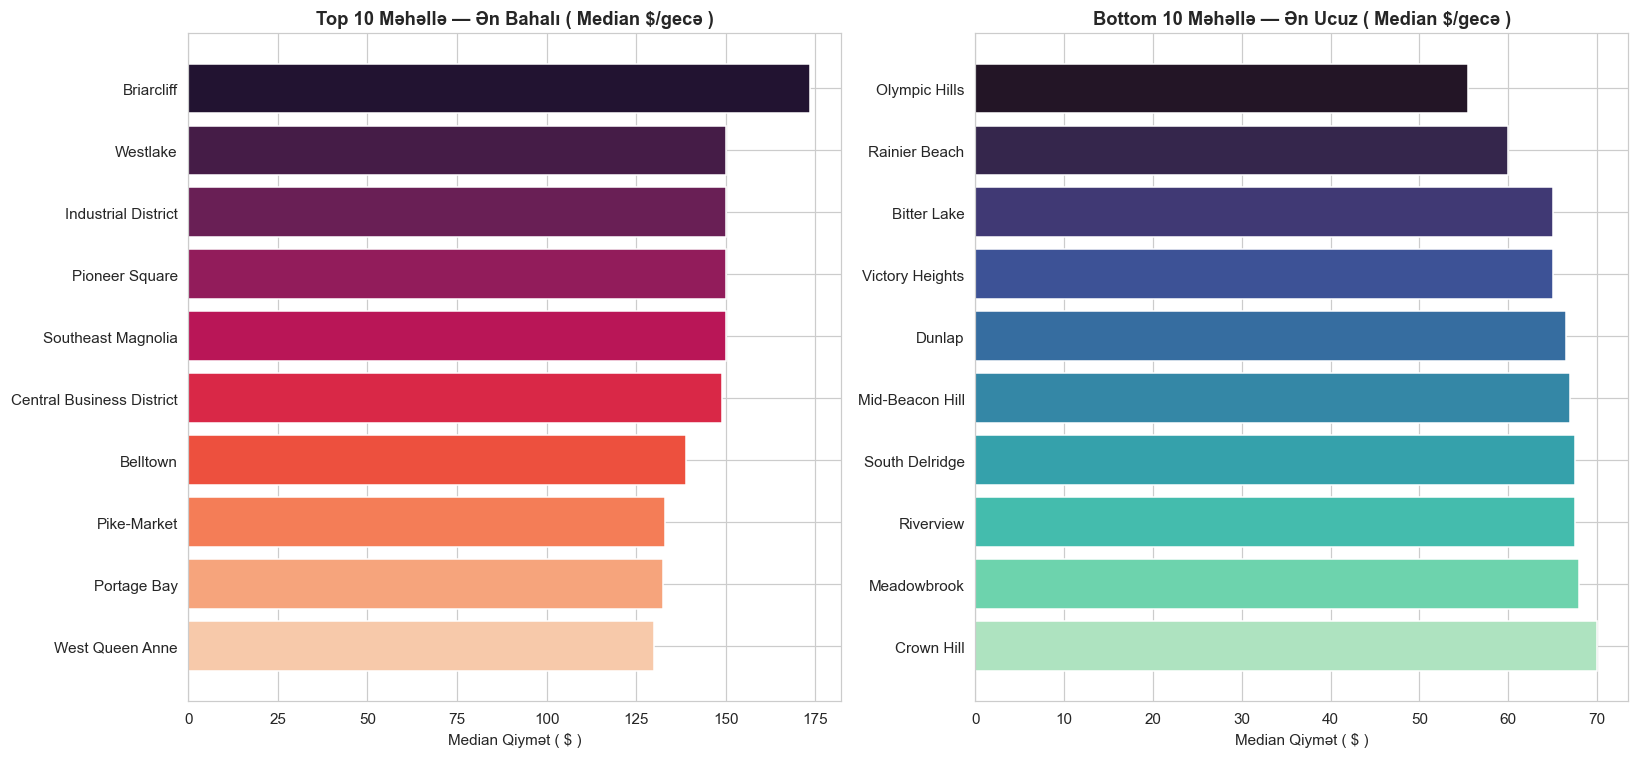

In [6]:
top10 = neighbourhood_reliable.sort_values('Median_Price', ascending=False).head(10)
bottom10 = neighbourhood_reliable.sort_values('Median_Price', ascending=True).head(10)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(top10.index[::-1], top10['Median_Price'][::-1], color=sns.color_palette('rocket', 10)[::-1])
axes[0].set_title('Top 10 Məhəllə — Ən Bahalı ( Median $/gecə )', fontweight='bold')
axes[0].set_xlabel('Median Qiymət ( $ )')
axes[1].barh(bottom10.index[::-1], bottom10['Median_Price'][::-1], color=sns.color_palette('mako', 10)[::-1])
axes[1].set_title('Bottom 10 Məhəllə — Ən Ucuz ( Median $/gecə )', fontweight='bold')
axes[1].set_xlabel('Median Qiymət ( $ )')
plt.tight_layout()
plt.savefig('neighbourhood_price_top_bottom.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
room_type_pct = (listings['room_type'].value_counts(normalize=True) * 100).round(2)
print("room_type paylanması:")
print(room_type_pct)

room_type paylanması:
room_type
Entire home/apt    66.55
Private room       30.38
Shared room         3.06
Name: proportion, dtype: float64


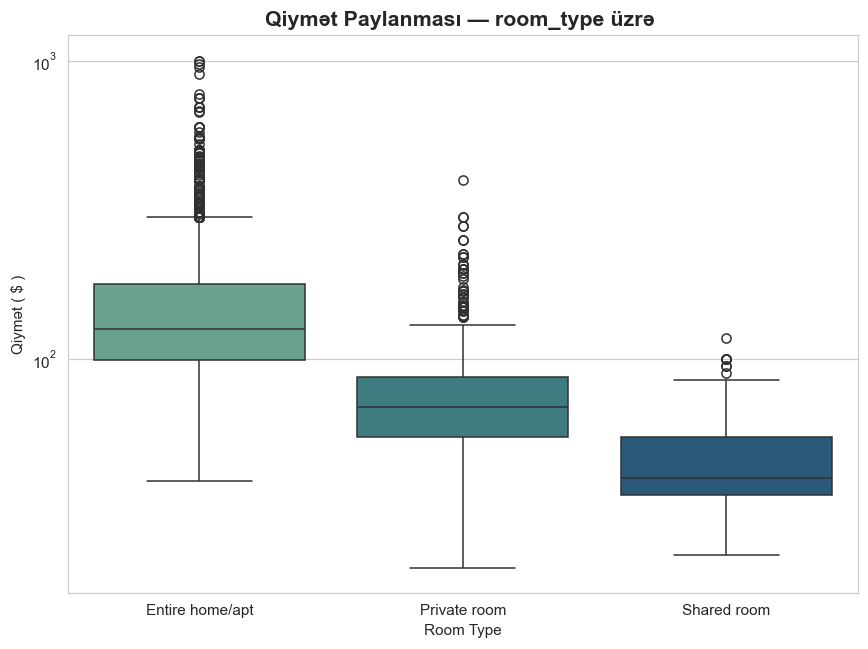

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
order = listings.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=listings, x='room_type', y='price', hue='room_type', order=order,
            palette='crest', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Qiymət Paylanması — room_type üzrə ', fontsize=14, fontweight='bold')
ax.set_xlabel('Room Type')
ax.set_ylabel('Qiymət ( $ )')
plt.tight_layout()
plt.savefig('room_type_price_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
calendar['month'] = calendar['date'].dt.month
monthly_price = calendar.groupby('month')['price'].median()
print("Aylıq median qiymət:")
print(monthly_price)
summer_avg = monthly_price.loc[[6, 7, 8]].mean()
winter_avg = monthly_price.loc[[12, 1, 2]].mean()
summer_premium = (summer_avg - winter_avg) / winter_avg * 100
print(f"\nYay ortası ( İyun-Avqust ): ${summer_avg:.2f}")
print(f"Qış ortası ( Dek-Yan-Fev ): ${winter_avg:.2f}")
print(f"Yay mövsümü əlavəsi: {summer_premium:.2f}%")

Aylıq median qiymət:
month
1     100.0
2     100.0
3     104.0
4     105.0
5     107.0
6     109.0
7     110.0
8     109.0
9     109.0
10    105.0
11    105.0
12    105.0
Name: price, dtype: float64

Yay ortası ( İyun-Avqust ): $109.33
Qış ortası ( Dek-Yan-Fev ): $101.67
Yay mövsümü əlavəsi: 7.54%


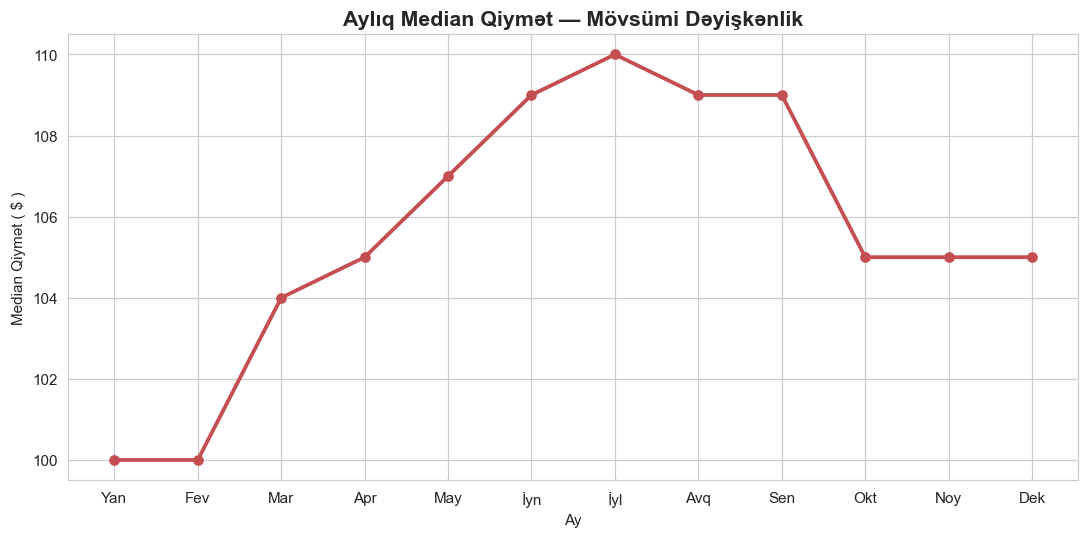

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
month_names = ['Yan', 'Fev', 'Mar', 'Apr', 'May', 'İyn', 'İyl', 'Avq', 'Sen', 'Okt', 'Noy', 'Dek']
ax.plot(range(1, 13), monthly_price.values, marker='o', linewidth=2.5, color='#C44E52')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Aylıq Median Qiymət — Mövsümi Dəyişkənlik', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Median Qiymət ( $ )')
plt.tight_layout()
plt.savefig('seasonal_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
instant_bench = listings.groupby('instant_bookable').agg(
    Median_Price=('price', 'median'),
    Avg_Occupancy=('occupancy_rate', 'mean'),
    Listing_Count=('id', 'count')
)
instant_bench

,Median_Price,Avg_Occupancy,Listing_Count
instant_bookable,,,
f,100.0,32.994639,3227
t,99.0,32.635190,591


In [12]:
price_diff_pct = (instant_bench.loc['t', 'Median_Price'] - instant_bench.loc['f', 'Median_Price']) / instant_bench.loc['f', 'Median_Price'] * 100
occ_diff_pct = (instant_bench.loc['t', 'Avg_Occupancy'] - instant_bench.loc['f', 'Avg_Occupancy']) / instant_bench.loc['f', 'Avg_Occupancy'] * 100
print(f"Instant bookable qiymət fərqi ( deyilə nisbətən ): {price_diff_pct:+.2f}%")
print(f"Instant bookable occupancy fərqi ( deyilə nisbətən ): {occ_diff_pct:+.2f}%")

Instant bookable qiymət fərqi ( deyilə nisbətən ): -1.00%
Instant bookable occupancy fərqi ( deyilə nisbətən ): -1.09%


In [13]:
reviews_occ_corr = listings['number_of_reviews'].corr(listings['occupancy_rate'])
min_nights_price_corr = listings['minimum_nights'].corr(listings['price'])
print(f"number_of_reviews <> occupancy_rate korrelyasiyası: r = {reviews_occ_corr:.3f}")
print(f"minimum_nights <> price korrelyasiyası: r = {min_nights_price_corr:.3f}")

number_of_reviews <> occupancy_rate korrelyasiyası: r = -0.094
minimum_nights <> price korrelyasiyası: r = 0.017


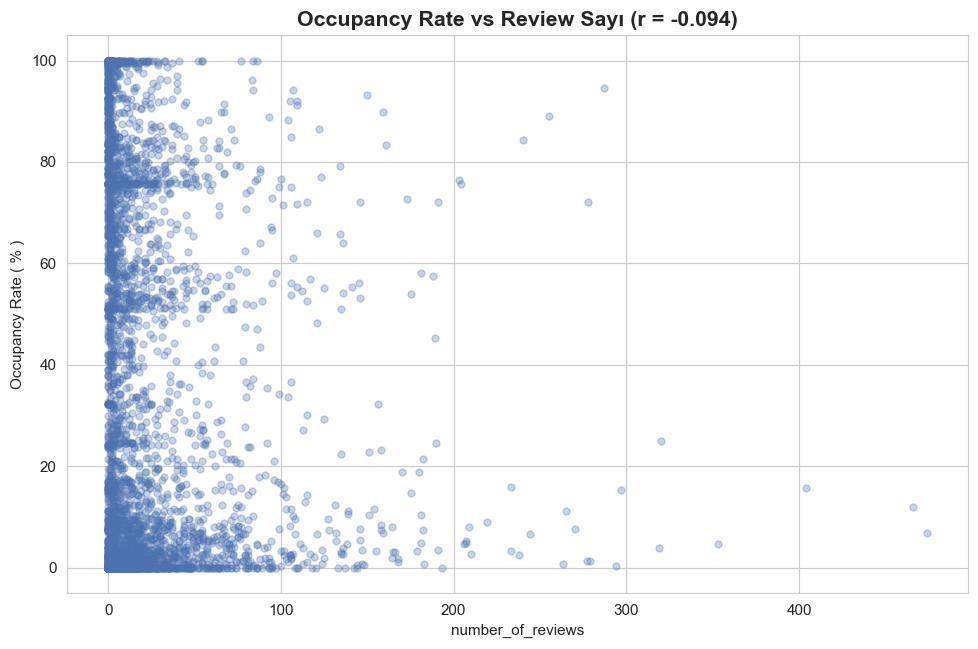

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(listings['number_of_reviews'], listings['occupancy_rate'], alpha=0.3, s=20, color='#4C72B0')
ax.set_title(f'Occupancy Rate vs Review Sayı (r = {reviews_occ_corr:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('number_of_reviews')
ax.set_ylabel('Occupancy Rate ( % )')
plt.tight_layout()
plt.savefig('occupancy_vs_reviews_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
listings['revenue_potential'] = (listings['occupancy_rate'] / 100) * listings['price'] * 365
neigh_revenue = listings.groupby('neighbourhood_cleansed').agg(
    Avg_Revenue_Potential=('revenue_potential', 'mean'),
    Median_Price=('price', 'median'),
    Avg_Occupancy=('occupancy_rate', 'mean'),
    Listing_Count=('id', 'count')
)
neigh_revenue_reliable = neigh_revenue[neigh_revenue['Listing_Count'] >= 5]
top10_revenue = neigh_revenue_reliable.sort_values('Avg_Revenue_Potential', ascending=False).head(10)
top10_revenue

,Avg_Revenue_Potential,Median_Price,Avg_Occupancy,Listing_Count
neighbourhood_cleansed,,,,
Montlake,37740.052632,125.0,43.677001,19
South Lake Union,25519.777778,110.0,54.672755,27
North Beach/Blue Ridge,25381.642857,97.0,48.610568,14
Madrona,22960.510638,125.0,43.485864,47
Belltown,22626.538462,139.0,37.571713,234
Portage Bay,21690.214286,132.5,25.636008,14
Genesee,21220.500000,97.0,42.409347,34
East Queen Anne,21181.012195,125.0,40.080187,82
View Ridge,21092.142857,125.0,33.189824,7


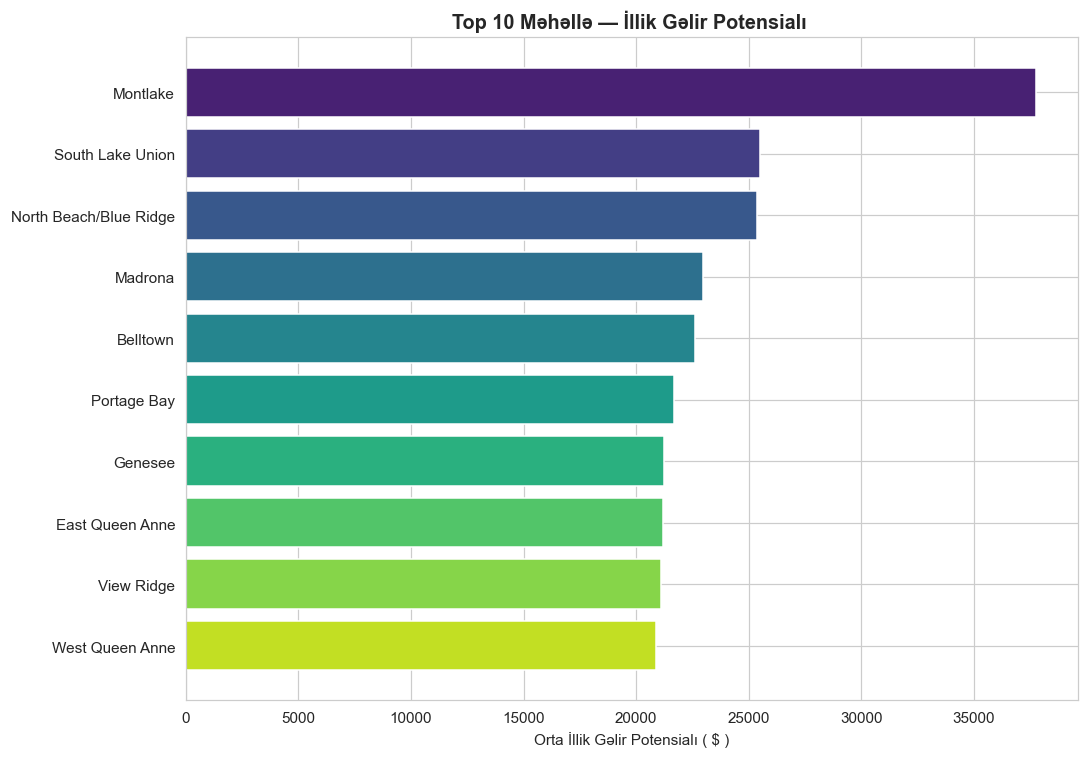

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('viridis', len(top10_revenue))
ax.barh(top10_revenue.index[::-1], top10_revenue['Avg_Revenue_Potential'][::-1], color=colors[::-1])
ax.set_title('Top 10 Məhəllə — İllik Gəlir Potensialı ', #( Occupancy × Qiymət × 365 )
              fontsize=13, fontweight='bold')
ax.set_xlabel('Orta İllik Gəlir Potensialı ( $ )')
plt.tight_layout()
plt.savefig('revenue_potential_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()